# 5R / SMURF 16S 流程：逐步复现（Python）

本 Notebook 用 Python 逐步复现本仓库 `mFiles/` 中的 MATLAB 流程（Fuks et al., *Microbiome* 2018），
并在示例数据 `example_fastq/`（两例乳腺癌 FFPE 样本）上验证：**结果与仓库自带的 `example_results/` 一致**。

| 步骤 | MATLAB 文件 | 本 Notebook 章节 |
|---|---|---|
| 参数与引物 | `get_configs.m` | §1 |
| 样本拆分 / 解压 | `split_files2directories.m`, `extract_sample_name.m` | §2 |
| 质量过滤 + 去重 | `read_fastq_save_unireads.m` | §3 |
| 按引物分配区域 | `read_unireads_save_split_to_regions.m`, `unambiguit_one_seq.m` | §4 |
| 载入 k-mer 数据库 | `load_bact_DB.m` | §5 |
| 似然矩阵 A | `build_A_matrices.m` | §6 |
| 过滤 / 合并 / EM | `solve_iterative_noisy.m`, `ml_em_iterative.m` | §7 |
| 分配 reads、注释、汇总 | `reconstruction_func.m`, `save_reconstruction_new_nogroups.m`, `scott_format_newer_func.m` | §8 |
| 与官方结果比对 | – | §9 |
| 扩展分析（引物覆盖度、读长敏感性、测序深度、建库） | – | §10 |

> 所有函数都在 `python_5R/smurf5r.py` 中，每个函数的注释都标注了对应的 `.m` 文件。
> 关键步骤（似然公式、EM 迭代、鸽巢检索）在 Notebook 中也直接展开写出，便于对照。

In [1]:
import os, sys, time, zipfile, glob
import numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt

REPO = os.path.abspath('..')
sys.path.insert(0, os.path.join(REPO, 'python_5R'))
import smurf5r as s

DB_DIR   = os.path.join(REPO, 'GG_5R')
FQ_DIR   = os.path.join(REPO, 'example_fastq')
WORK     = os.path.join(REPO, 'python_5R', 'work')       # 解压/缓存目录（已在 .gitignore 中）
os.makedirs(WORK, exist_ok=True)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. 参数与 5 对多重引物（`get_configs.m`）

5R 的核心思想：**用 5 对引物在一个多重 PCR 中同时扩增 16S rRNA 的 5 个短区域**（适合降解严重的 FFPE / 低生物量样本），
每个区域单独看分辨率有限，但 SMURF 把 5 个区域的 reads 放到**同一个似然模型**里联合求解，从而得到接近全长 16S 的分辨率。

关键参数：
* `kmer_len = 126`：每端只使用前 126 nt（示例数据为 2×126 bp）。README 建议取“质量开始低于 Q30 的位置”。
* 数据库预存的 k-mer 长度为 160（`RL160`），因此 `kmer_len` 最大 160。
* 引物允许 ≤2 个错配；read 与数据库 k-mer 允许 ≤2 个错配；每碱基错误率 `pe = 0.005`。

In [2]:
cfg = s.Config(kmer_len=126)
# E. coli 16S 上的大致位置（由引物序列比对 J01859 得到，便于理解覆盖的可变区）
ecoli_pos = [(104, 336, 'V2'), (338, 531, 'V3'), (685, 929, 'V5'), (926, 1086, 'V6'), (1175, 1392, 'V8')]
prim = pd.DataFrame([{'region': f'R{i+1}', 'forward': f, 'reverse': r,
                      'F len': len(f), 'R len': len(r),
                      'F variants': len(s.expand_degenerate(f)), 'R variants': len(s.expand_degenerate(r)),
                      'E.coli approx.': f'{a}-{b}', 'variable region': v}
                     for i, ((f, r), (a, b, v)) in enumerate(zip(cfg.primers, ecoli_pos))])
prim

,region,forward,reverse,F len,R len,F variants,R variants,E.coli approx.,variable region
0,R1,TGGCGAACGGGTGAGTAA,CCGTGTCTCAGTCCCARTG,18,19,1,2,104-336,V2
1,R2,ACTCCTACGGGAGGCAGC,GTATTACCGCGGCTGCTG,18,18,1,1,338-531,V3
2,R3,GTGTAGCGGTGRAATGCG,CCCGTCAATTCMTTTGAGTT,18,20,2,2,685-929,V5
3,R4,GGAGCATGTGGWTTAATTCGA,CGTTGCGGGACTTAACCC,21,18,2,1,926-1086,V6
4,R5,GGAGGAAGGTGGGGATGAC,AAGGCCCGGGAACGTATT,19,18,1,1,1175-1392,V8


In [3]:
# 从数据库 match_pos 字段估计每个扩增子的长度（正向引物起点 -> 反向引物起点 + 反向引物长度）
import scipy.io as sio
amp_len = {}
for i in range(1, 6):
    d = sio.loadmat(os.path.join(DB_DIR, f'{cfg.db_file_prefix()}_region{i}.mat'), variable_names=['match_pos_fwd', 'match_pos_rvs', 'indInValue'])
    f, r = d['match_pos_fwd'][:, 0], d['match_pos_rvs'][:, 0]
    ok = (d['indInValue'].ravel() > 0) & ~np.isnan(f) & ~np.isnan(r)
    amp_len[f'R{i}'] = np.percentile(r[ok] - f[ok] + cfg.primers_len[i-1, 1], [5, 50, 95])
pd.DataFrame(amp_len, index=['5%', 'median', '95%']).T.assign(**{'overlap at 2x126 (median)': lambda d: 252 - d['median']})

,5%,median,95%,overlap at 2x126 (median)
R1,215.0,232.0,241.0,20.0
R2,173.0,193.0,199.0,59.0
R3,241.0,244.0,246.0,8.0
R4,159.0,160.0,164.0,92.0
R5,216.0,217.0,218.0,35.0


简并碱基（R=A/G、M=A/C、W=A/T）由 `unambiguit_one_seq.m` 展开成所有具体序列，例如：

In [4]:
print(s.expand_degenerate('CCGTGTCTCAGTCCCARTG'))
print(s.expand_degenerate('CCCGTCAATTCMTTTGAGTT'))

['CCGTGTCTCAGTCCCAATG', 'CCGTGTCTCAGTCCCAGTG']
['CCCGTCAATTCATTTGAGTT', 'CCCGTCAATTCCTTTGAGTT']


## 2. 样本与 FASTQ（`split_files2directories.m`、`extract_sample_name.m`）

Illumina 文件名 `SAMPLE_L001_R1_001.fastq` 中，`_L0xx` 之前的部分即样本名。MATLAB 版会自动解压 `.zip/.gz`，处理完再删除。

In [5]:
for z in sorted(glob.glob(os.path.join(FQ_DIR, '*', '*.fastq.zip'))):
    with zipfile.ZipFile(z) as zf:
        for n in zf.namelist():
            if not os.path.exists(os.path.join(WORK, n)):
                zf.extract(n, WORK)
pairs = s.find_sample_pairs(WORK)
for name, pp in pairs.items():
    print(name, '->', [os.path.basename(x) for x in pp[0]])

RDB123_ATGAGTGC -> ['RDB123_ATGAGTGC_L006_R1_001.fastq', 'RDB123_ATGAGTGC_L006_R2_001.fastq']
RDB1_TTGGTGCA -> ['RDB1_TTGGTGCA_L001_R1_001.fastq', 'RDB1_TTGGTGCA_L001_R2_001.fastq']


In [6]:
SAMPLE = 'RDB1_TTGGTGCA'
r1, r2 = pairs[SAMPLE][0]
seqs1, quals1 = s._read_fastq(r1)
seqs2, quals2 = s._read_fastq(r2)
print(f'{len(seqs1):,} read pairs; read length distribution:', pd.Series(map(len, seqs1)).value_counts().to_dict())
for i in range(3):
    print('R1', seqs1[i][:60], '...  R2', seqs2[i][:40], '...')

299,346 read pairs; read length distribution: {126: 299346}
R1 ACTCCTACGGGAGGCAGCAGTAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAA ...  R2 GTATTACCGCGGCTGCTGGCACGTAGTTAGCCGTCCCTTT ...
R1 TGGCGAACGGGTGAGTAATGTATCGGAACGTGCCCAGTCGTGGGGGATAACTGCTCGAAA ...  R2 CCGTGTCTCAGTCCCAGTGTGGCTGGTCGTCCTCTCAGAC ...
R1 GGAGCATGTGGTTTAATTCGATGCAACGCGAAGAACCTTACCAAGGCTTGACATGTTCTC ...  R2 CGTTGCGGGACTTAACCCAACATCTCACGACACGAGCTGA ...


## 3. 质量过滤 + 去重（`read_fastq_save_unireads.m`）

对每一对 read：
1. 两端长度都 ≥ `kmer_len`，截取前 `kmer_len` 个碱基；
2. 不含 N（`max_num_Ns = 0`）；
3. Q > 30 的碱基比例 ≥ 75%，且 Q < 10 的碱基 < 3 个（两端都需满足）。

合格的 read 对拼成一条 `[R1 | R2]`（长度 2×126=252），再**完全相同去重**，记录每条唯一序列的计数 `freq`。

> ⚠️ 原 MATLAB 代码第 124 行在判断 R2 时写成了 `sum(q1<10,2)`（误用 R1 质量）。`cfg.faithful=True` 时我们**保留此 bug** 以便逐位复现；§10 会评估修正它的影响。

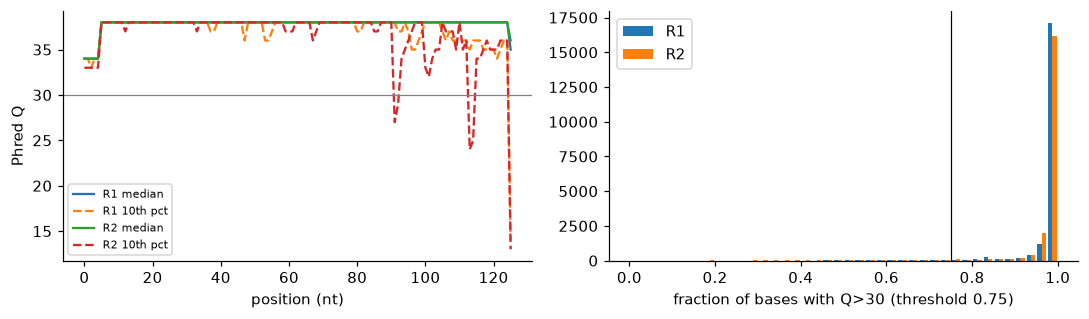

In [7]:
Q1 = s.to_u8(quals1[:20000]).astype(int) - 33
Q2 = s.to_u8(quals2[:20000]).astype(int) - 33
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
for q, lab in [(Q1, 'R1'), (Q2, 'R2')]:
    ax[0].plot(np.median(q, 0), label=f'{lab} median'); ax[0].plot(np.percentile(q, 10, 0), '--', label=f'{lab} 10th pct')
ax[0].axhline(30, color='grey', lw=.8); ax[0].set_xlabel('position (nt)'); ax[0].set_ylabel('Phred Q'); ax[0].legend(fontsize=7)
ax[1].hist([(Q1 > 30).mean(1), (Q2 > 30).mean(1)], bins=40, label=['R1', 'R2']); ax[1].axvline(.75, color='k', lw=.8)
ax[1].set_xlabel('fraction of bases with Q>30 (threshold 0.75)'); ax[1].legend(); plt.tight_layout()

In [8]:
stats = s.ReadsStats(5)
t = time.time()
Suni, freq = s.quality_filter_pairs(r1, r2, cfg, stats)
print(f'{time.time()-t:.1f}s')
print(stats.to_series().to_string())
print(f'unique read pairs: {len(freq):,}; top-5 counts: {np.sort(freq)[::-1][:5]}')

5.7s
Number of loaded reads    299346
Number of long reads      299346
Number of good reads      286199
unique read pairs: 32,471; top-5 counts: [37100  7488  7144  6532  6494]


## 4. 按引物把 read 对分配到 5 个区域（`read_unireads_save_split_to_regions.m`）

* 先把 R2 部分**反向互补**，于是整条序列为 16S 正链方向：`[正向引物 … R1 … | … rc(R2) … 反向引物的反向互补]`。
* 对每个区域：开头 `len(F)` 个碱基与正向引物（任一简并版本）的错配 ≤ 2，**且**末尾 `len(R)` 个碱基与反向引物反向互补的错配 ≤ 2，则归入该区域。
* 去掉两端引物，得到长度 `2·126 − len(F) − len(R)` 的“配对 read”。
* 注意：5 个扩增子（含引物）长度约 **232 / 193 / 244 / 160 / 217 bp**（见 §1），都短于 2×126 = 252，所以 R1 与 R2 **实际是重叠的**
  （R4 重叠约 90 nt）。流程并不合并双端，而是直接拼接：重叠部分的碱基在 Hamming 距离中被计算两次，
  数据库 k-mer 也按同样方式构造，因此模型自洽，但浪费了用重叠区纠错的机会（见改进建议）。

In [9]:
regions = s.split_to_regions(Suni, freq, cfg, stats)
pd.DataFrame([{'region': f'R{i+1}', 'unique reads': len(r['freq']), 'read count': int(r['freq'].sum()),
               'read length (no primers)': r['reads'].shape[1]} for i, r in enumerate(regions)])

Mapped to primers 88% of unique reads, 98% of read counts


,region,unique reads,read count,read length (no primers)
0,R1,4039,33189,215
1,R2,12019,134783,216
2,R3,1767,10763,214
3,R4,4328,37922,213
4,R5,6382,63852,215


## 5. k-mer 数据库（`load_bact_DB.m`）

`GG_5R/` 中每个区域一个 `.mat`，来自 GreenGenes 13_5（1,402,801 条唯一 16S，含 ≤3 个简并碱基的序列已展开）。每个文件包含：

| 变量 | 形状 | 含义 |
|---|---|---|
| `values` | K × 320 | 每个**唯一扩增子**的 `[前 160 nt | 后 160 nt]`（含引物、正链方向） |
| `indInValue` | 1,402,801 × 1 | 每条参考序列对应 `values` 的行号；0 = 引物错配 >2，不被扩增 |
| `is_perfect_match` | 1,402,801 × 1 | 两端引物均 0 错配 |
| `match_pos_fwd/rvs`, `Header_amp`, `Dictionary` | | 构建时的辅助信息（流程中未使用） |

载入时把每个 k-mer 截成与实验 read 完全相同的形状：去掉引物、每端只保留 `kmer_len`，再去重。
**许多参考序列在某个区域共享同一个 k-mer**——这正是单区域分辨率有限的原因。

In [10]:
t = time.time()
dbs = s.load_bact_db(DB_DIR, cfg)
print(f'loaded in {time.time()-t:.0f}s')
nB = len(dbs[0]['indInSeqs'])
pd.DataFrame([{'region': f'R{i+1}', 'unique k-mers': d['kmers'].shape[0], 'k-mer length': d['kmers'].shape[1],
               'amplified seqs': (d['indInSeqs'] > 0).mean(), 'perfect primer match': d['is_perfect_match'].mean(),
               'mean seqs per k-mer': (d['indInSeqs'] > 0).sum() / d['kmers'].shape[0]} for i, d in enumerate(dbs)]).round(3)

Region 1: 254,951 unique k-mers (len 215), 1,181,229 amplified seqs [6.4s]


Region 2: 212,346 unique k-mers (len 216), 1,334,832 amplified seqs [6.3s]


Region 3: 286,603 unique k-mers (len 214), 1,285,094 amplified seqs [9.6s]


Region 4: 138,216 unique k-mers (len 213), 1,052,621 amplified seqs [2.9s]


Region 5: 197,901 unique k-mers (len 215), 1,193,799 amplified seqs [7.6s]
loaded in 33s


,region,unique k-mers,k-mer length,amplified seqs,perfect primer match,mean seqs per k-mer
0,R1,254951,215,0.842,0.127,4.633
1,R2,212346,216,0.952,0.800,6.286
2,R3,286603,214,0.916,0.535,4.484
3,R4,138216,213,0.750,0.442,7.616
4,R5,197901,215,0.851,0.200,6.032


分类信息 `taxonomy_db.mat`（7 级：domain → species）。MATLAB cell 数组读入较慢（~1.5 min），这里缓存为 pickle。

In [11]:
tax_cache = os.path.join(WORK, 'taxa.pkl')
if os.path.exists(tax_cache):
    taxa = pd.read_pickle(tax_cache)
else:
    headers, taxa = s.load_headers_taxonomy(DB_DIR)
    taxa.to_pickle(tax_cache)
print(taxa.shape)
print('fraction of placeholder names  genus: %.2f  species: %.2f' % (
      taxa.genus.str.startswith('Assigned').mean(), taxa.species.str.startswith('Assigned').mean()))
taxa.head()

(1402801, 7)


fraction of placeholder names  genus: 0.19  species: 0.50


,domain,phylum,class,order,family,genus,species
0,Bacteria,Proteobacteria,Gammaproteobacteria,Alteromonadales,Pseudoalteromonadaceae,Pseudoalteromonas,Pseudoalteromonas atlantica
1,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,S24-7,Assigned genus699,Assigned species1
2,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Psychrobacter,Psychrobacter cibarius
3,Bacteria,Chloroflexi,Anaerolineae,S0208,Unknown family,Assigned genus65,Assigned species9
4,Bacteria,Fusobacteria,Fusobacteriia,Fusobacteriales,Leptotrichiaceae,Leptotrichia,Assigned species4


## 6. 似然矩阵 A（`build_A_matrices.m`）

**6a 低丰度过滤**：区域内计数 < max(1e-4 × 区域总数, 2) 的唯一 read 被丢弃（去除大部分测序错误产生的长尾）。

**6b 似然**：对区域 r 中的唯一 read y 与参考序列 j，设 d 为 read 与 j 在该区域 k-mer 的 Hamming 距离（只考虑替换，不考虑插入缺失）：

$$A_r[y,j]=\Pr(y\mid j)=\begin{cases}(1-p_e)^{L-d}\,(p_e/3)^{d}, & d\le 2\\ 0, & d>2\end{cases}$$

其中 $L$ 为去引物后的 read 长度（~215 nt），$p_e=0.005$。

**6c 计算技巧**：MATLAB 对每条 read 与全部 ~20 万个 k-mer 做暴力比较。这里用**鸽巢原理**：把序列切成 3 段，
距离 ≤ 2 的两条序列至少有 1 段完全相同 → 先用 3 张哈希表找候选，再精确计算距离。结果相同、速度快约 1000 倍。下面先验证二者等价：

In [12]:
rr = 2
reads2, F2 = s.unique_rows_with_counts(regions[rr-1]['reads'], regions[rr-1]['freq'].astype(float))
reads2 = reads2[F2 >= max(cfg.min_read_freq * F2.sum(), cfg.min_read_count)]
kmers = dbs[rr-1]['kmers']
idx = s.KmerIndex(kmers, cfg.nMM_cut)
rng = np.random.default_rng(0)
ok = True
for y in rng.choice(len(reads2), 30, replace=False):
    brute = (kmers != reads2[y]).sum(1)                       # MATLAB: sum(bsxfun(@ne, kmers, read), 2)
    bk = np.flatnonzero(brute <= 2)
    fk, fd = idx.query(reads2[y], 2)
    ok &= np.array_equal(np.sort(bk), np.sort(fk)) and np.array_equal(brute[np.sort(fk)], fd[np.argsort(fk)])
print('pigeonhole index == brute force on 30 random reads:', ok)

pigeonhole index == brute force on 30 random reads: True


In [13]:
t = time.time()
dat0 = s.build_A_matrices(dbs, regions, cfg, stats)
print(f'{time.time()-t:.1f}s')
A = dat0['A'][1]
vals = np.unique(np.round(A.data / ((1 - cfg.pe) ** dat0['reads'][1].shape[1]), 6))
print('Region 2: distinct A values / perfect-match probability =', vals, '(d = 2, 1, 0)')

Region 1: 258 unique reads (>= 3.3), A nnz = 613,944 [0.9s]


Region 2: 391 unique reads (>= 13.5), A nnz = 2,600,969 [1.1s]


Region 3: 258 unique reads (>= 2.0), A nnz = 3,727,058 [2.0s]


Region 4: 304 unique reads (>= 3.8), A nnz = 1,195,471 [0.7s]


Region 5: 289 unique reads (>= 6.4), A nnz = 1,584,075 [1.0s]
5.7s
Region 2: distinct A values / perfect-match probability = [3.000e-06 1.675e-03 1.000e+00] (d = 2, 1, 0)


## 7. 求解混合比例（`solve_iterative_noisy.m` + `ml_em_iterative.m`）

**7a 候选过滤**：若参考序列 j 在区域 r 的两个引物都是 0 错配（`is_perfect_match`，理论上必然扩增），
那么区域 r 中**至少要有一条与 j 完全匹配（d=0）的 read**，否则 j 被排除。另外 j 至少要有一条匹配的 read。

**7b 拼接与归一化**：把 5 个区域的 A 纵向拼接为一个矩阵 $A$；观测向量 $y$ = 各 read 计数 / **所有区域总计数**。
每一列再除以该细菌被扩增的区域数 $n_j$（使每列总和≈1）。

**7c 合并不可区分的细菌**：列完全相同的参考序列在这 5 个区域上无法区分，合并为一个 **group**（输出的最小单位）。

**7d 去除“被包含”的细菌**：若 i 的非零 read 集合是 j 的**真子集**，删除 i（简约性启发式）。

**7e EM**（泊松/多项式混合的最大似然，与 MLEM / Richardson–Lucy 同形）：

$$\theta = A x,\qquad x_j \leftarrow x_j\sum_y A_{yj}\frac{y_y}{\theta_y}$$

直到 $\sum_j |1-\text{factor}_j|\,x_j < 5\times10^{-7}$。

**7f** 最终丰度：$x_j / n_j$ 再归一化——把“reads 份额”换算为“细胞（16S 拷贝）份额”。

下面先用模块完成 7a–7f：

In [14]:
bfreq, meta, keep_col, dbg = s.solve_iterative_noisy(dat0, cfg, stats, return_debug=True)
print(f"candidates after filter: {dbg['n_candidates']:,} | unique groups: {dbg['n_groups']:,} | "
      f"final groups with x>1e-10: {dbg['n_final']}")

Removed 8844 included bacteria out of 10189


EM: 2948 iterations, L1 error 5.00e-07, 0.5s
candidates after filter: 117,430 | unique groups: 10,189 | final groups with x>1e-10: 404


EM 在这里手写展开（与 `ml_em_iterative` 相同的迭代公式），作用于 7a–7d 之后的候选矩阵 `dbg['A_em']`，并记录收敛曲线：

candidate matrix for EM: (1414, 1345)


groups with x>1e-10: 404 (module: 404 )
2948 iterations


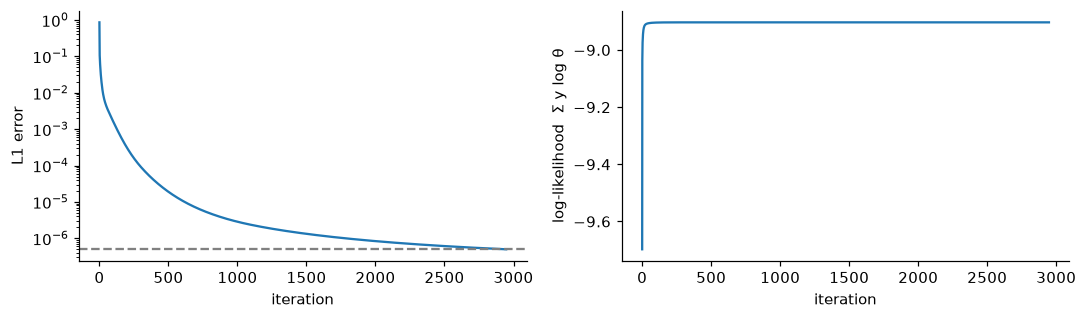

In [15]:
def em_trace(A, y, tol=5e-7, max_iter=10000):
    A = sp.csc_matrix(A); AT = A.T.tocsr()
    x = AT @ y; x /= x.sum()                  # 初值: A^T y
    errs, ll = [], []
    for it in range(max_iter):
        theta = A @ x                          # 预测的 read 分布
        factor = AT @ (y / (theta + s.EPS))    # 乘性更新因子
        err = np.abs(1 - factor) @ x
        errs.append(err); ll.append(y @ np.log(theta + s.EPS))
        x = x * factor
        if err < tol: break
    x[x < 1e-10] = 0
    return x / x.sum(), np.array(errs), np.array(ll)

print('candidate matrix for EM:', dbg['A_em'].shape)
x_tr, errs, ll = em_trace(dbg['A_em'], dbg['y'])
print('groups with x>1e-10:', int((x_tr > 1e-10).sum()), '(module:', dbg['n_final'], ')')
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].semilogy(errs); ax[0].axhline(5e-7, ls='--', c='grey'); ax[0].set_xlabel('iteration'); ax[0].set_ylabel('L1 error')
ax[1].plot(ll); ax[1].set_xlabel('iteration'); ax[1].set_ylabel('log-likelihood  Σ y log θ')
plt.tight_layout(); print(len(errs), 'iterations')

## 8. 分配 reads、分类注释与汇总

* **assigned reads**（`reconstruction_func.m`）：按后验 $\Pr(j\mid y)\propto A_{yj}x_j$ 把每条 read 的计数分给各 group。
* **注释**（`save_reconstruction_new_nogroups.m`）：一个 group 可能包含成百上千条参考序列，各自分类可能不同；
  每一级统计 group 内各分类所占比例。
* **硬决策**（`scott_format_newer_func.m`）：在 species 级，**整个 group 的丰度赋给占比最高的分类**（并列取字典序最前者），
  名称中的 `Assigned` 改为 `Unknown`，最后跨样本合并为丰度表。

In [16]:
assigned = s.assign_reads(dat0, bfreq, keep_col)
tab = s.annotate_groups(bfreq, assigned, meta, taxa)
print('groups:', len(tab), '| total assigned reads:', int(tab.reads.sum()))
print('group size (number of reference sequences) median / max:', int(tab.group_size.median()), '/', tab.group_size.max())
print('groups whose majority species covers <50% of members:', int((tab.majority_fraction < .5).sum()))
tab.sort_values('freq', ascending=False).head(15)[['phylum', 'genus', 'species', 'freq', 'reads', 'group_size', 'majority_fraction']]

groups: 404 | total assigned reads: 205599
group size (number of reference sequences) median / max: 2 / 586
groups whose majority species covers <50% of members: 19


,phylum,genus,species,freq,reads,group_size,majority_fraction
1,Actinobacteria,Propionibacterium,Propionibacterium acnes,0.082565,21393,40,1.000000
167,Actinobacteria,Corynebacterium,Unknown species1715,0.078115,6939,7,0.571429
181,Actinobacteria,Propionibacterium,Propionibacterium acnes,0.075369,19529,1,1.000000
0,Actinobacteria,Propionibacterium,Propionibacterium acnes,0.058621,15188,586,1.000000
3,Firmicutes,Lactococcus,Lactococcus lactis,0.045511,7794,407,0.660934
40,Proteobacteria,Pelomonas,Pelomonas puraquae,0.033199,5257,18,0.611111
371,Proteobacteria,Paracoccus,Paracoccus aminovorans,0.019190,4972,1,1.000000
35,Actinobacteria,Micrococcus,Micrococcus luteus,0.018767,4862,66,1.000000
344,Firmicutes,Lactococcus,Unknown species27,0.013275,3440,1,1.000000
262,Firmicutes,Streptococcus,Streptococcus mitis,0.012148,2099,3,0.666667


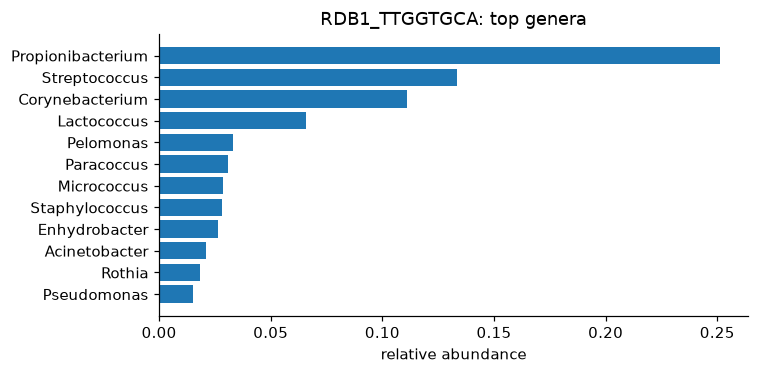

In [17]:
gen = tab.groupby('genus').freq.sum().sort_values(ascending=False)
top = gen.head(12)
plt.figure(figsize=(7, 3.5)); plt.barh(top.index[::-1], top.values[::-1]); plt.xlabel('relative abundance')
plt.title(f'{SAMPLE}: top genera'); plt.tight_layout()

## 9. 两个样本完整运行，并与官方 MATLAB 结果比对

In [18]:
results = {}
for name, [(f1, f2)] in pairs.items():
    t = time.time()
    results[name] = s.run_sample(f1, f2, dbs, cfg, taxa)
    print(f'== {name}: {time.time()-t:.1f}s')
species_tab, totals = s.merge_samples({k: v['table'] for k, v in results.items()})
s.write_matlab_style_table(species_tab, totals, os.path.join(WORK, 'SPECIES_python_5R_example.txt'))
totals

Mapped to primers 88% of unique reads, 98% of read counts


Region 1: 272 unique reads (>= 2.0), A nnz = 83,413 [0.7s]


Region 2: 187 unique reads (>= 6.8), A nnz = 164,736 [0.7s]


Region 3: 207 unique reads (>= 2.4), A nnz = 258,246 [0.8s]


Region 4: 113 unique reads (>= 6.1), A nnz = 214,972 [0.6s]


...

Region 5: 289 unique reads (>= 6.4), A nnz = 1,584,075 [0.9s]


Removed 8844 included bacteria out of 10189


EM: 2948 iterations, L1 error 5.00e-07, 0.5s


== RDB1_TTGGTGCA: 15.3s


RDB123_ATGAGTGC    183701
RDB1_TTGGTGCA      205599
dtype: int64

In [19]:
def read_matlab_table(p):
    d = pd.read_csv(p, sep='\t', skiprows=1)
    return d.set_index(list(d.columns[:7]))

ml = read_matlab_table(os.path.join(REPO, 'example_results', '5R_SMURF_example.txt'))
py = species_tab.copy(); py.index.names = ml.index.names
j = ml.join(py, how='outer', lsuffix=' (MATLAB)', rsuffix=' (Python)').fillna(0)
summary = []
for c in ml.columns:
    a, b = j[f'{c} (MATLAB)'], j[f'{c} (Python)']
    summary.append({'sample': c, 'species MATLAB': int((a > 0).sum()), 'species Python': int((b > 0).sum()),
                    'shared': int(((a > 0) & (b > 0)).sum()), 'max |Δ|': (a - b).abs().max(), 'Pearson r': np.corrcoef(a, b)[0, 1]})
print('rows: MATLAB', len(ml), '| Python', len(py), '| union', len(j))
pd.DataFrame(summary)

rows: MATLAB 328 | Python 328 | union 328


,sample,species MATLAB,species Python,shared,max |Δ|,Pearson r
0,RDB123_ATGAGTGC,67,67,67,2.656677e-06,1.0
1,RDB1_TTGGTGCA,286,286,286,8.493325e-07,1.0


In [20]:
stats_ml = pd.read_csv(os.path.join(REPO, 'example_results', 'ReadCountStats_5R_SMURF_example.txt'), sep='\t', index_col=0)
stats_py = pd.DataFrame({k: v['stats'].to_series() for k, v in results.items()}).T[stats_ml.columns]
print('read-count statistics identical:', (stats_ml.values == stats_py.values).all())
stats_py.T.head(12)

read-count statistics identical: True


,RDB123_ATGAGTGC,RDB1_TTGGTGCA
Number of loaded reads,231943,299346
Number of long reads,231943,299346
Number of good reads,222413,286199
Number of reads mapped to region1,16800,33189
After low abundance filter1,15990,29584
Number of reads mathced to DB1,15688,28640
Count of maximal unmatched read1,58,359
Count of all unmatched read1,302,944
Number of reads mapped to region2,68372,134783
After low abundance filter2,57762,120827


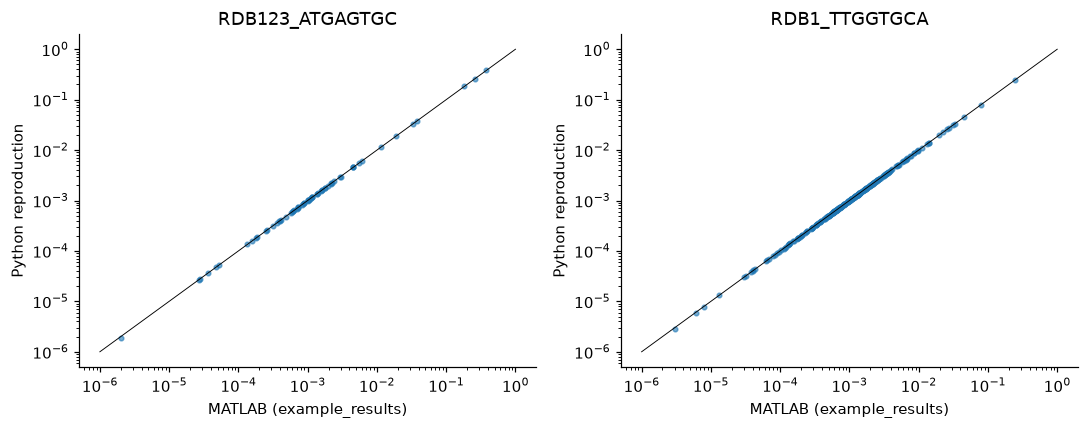

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a_, c in zip(ax, ml.columns):
    x_, y_ = j[f'{c} (MATLAB)'], j[f'{c} (Python)']
    m = (x_ > 0) | (y_ > 0)
    a_.loglog(x_[m] + 1e-6, y_[m] + 1e-6, 'o', ms=3, alpha=.6); a_.plot([1e-6, 1], [1e-6, 1], 'k-', lw=.6)
    a_.set_title(c); a_.set_xlabel('MATLAB (example_results)'); a_.set_ylabel('Python reproduction')
plt.tight_layout()

**结论**：所有 read 计数统计逐项一致；328 个物种的检出集合完全一致；丰度最大差异约 3×10⁻⁶，来自 EM 的收敛容差
（MATLAB 版本每运行 60 秒会剪枝一次，迭代路径与机器速度有关），`Total # of reads` 相差 ≤6 条也来源于此。

## 10. 扩展分析（为改进建议提供依据）

### 10.1 引物 in-silico 覆盖度（按门统计）

`R*_amp`：该区域可被扩增（两端引物错配均 ≤2）的参考序列比例；`R*_0mm`：两端 0 错配的比例；`n_regions`：平均可扩增区域数。

In [22]:
cov = s.primer_coverage(DB_DIR, taxa, cfg, rank='phylum', top=15)
cov.round(3)

,n_seqs,R1_amp,R1_0mm,R2_amp,R2_0mm,R3_amp,R3_0mm,R4_amp,R4_0mm,R5_amp,R5_0mm,n_regions
phylum,,,,,,,,,,,,
Firmicutes,456548.0,0.951,0.107,0.985,0.884,0.975,0.884,0.915,0.726,0.902,0.214,4.728
Proteobacteria,403204.0,0.871,0.165,0.985,0.929,0.918,0.417,0.960,0.499,0.957,0.307,4.691
Actinobacteria,175183.0,0.985,0.317,0.982,0.676,0.979,0.649,0.551,0.173,0.757,0.149,4.252
Bacteroidetes,162169.0,0.624,0.000,0.983,0.916,0.934,0.012,0.116,0.041,0.800,0.008,3.458
Chloroflexi,25023.0,0.539,0.012,0.953,0.136,0.921,0.040,0.676,0.000,0.888,0.214,3.976
Cyanobacteria,21644.0,0.946,0.013,0.963,0.701,0.965,0.697,0.915,0.158,0.927,0.045,4.715
Acidobacteria,19671.0,0.790,0.091,0.976,0.905,0.903,0.843,0.699,0.400,0.984,0.641,4.352
Euryarchaeota,16771.0,0.000,0.000,0.000,0.000,0.008,0.000,0.000,0.000,0.000,0.000,0.008
Planctomycetes,16478.0,0.405,0.001,0.428,0.029,0.923,0.116,0.638,0.001,0.080,0.002,2.473


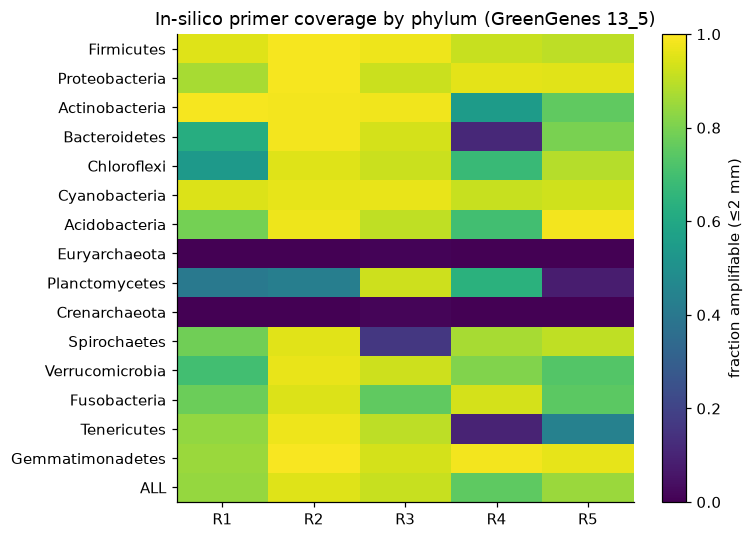

In [23]:
cols = [f'R{i}_amp' for i in range(1, 6)]
plt.figure(figsize=(7, 5)); im = plt.imshow(cov[cols].values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.yticks(range(len(cov)), cov.index); plt.xticks(range(5), [f'R{i}' for i in range(1, 6)]); plt.colorbar(im, label='fraction amplifiable (≤2 mm)')
plt.title('In-silico primer coverage by phylum (GreenGenes 13_5)'); plt.tight_layout()

观察：
* **古菌几乎完全不覆盖**（Euryarchaeota / Crenarchaeota 平均 <0.02 个区域）。
* **Bacteroidetes**：R1 引物 0 错配比例为 0，R4 可扩增仅 ~12%，R3 0 错配 ~1%——而它是肠道最主要的门之一。
* **Actinobacteria** R4 仅 55%；**Planctomycetes** R1/R2/R5 覆盖差；R1 / R5 的整体 0 错配率仅 13% / 20%。
* 允许 2 个错配的 in-silico 结果偏乐观：真实 PCR 中 3′ 端错配会显著降低扩增效率，这会造成区域间扩增偏倚，而模型假设各区域效率相同。

### 10.2 读长 `kmer_len` 的影响（分辨率 vs. 质量）

In [24]:
r1, r2 = pairs[SAMPLE][0]
rows = []
for L in [100, 126]:
    c = s.Config(kmer_len=L)
    d_ = dbs if L == 126 else s.load_bact_db(DB_DIR, c)
    st = s.ReadsStats(5)
    Su, fr = s.quality_filter_pairs(r1, r2, c, st)
    rg = s.split_to_regions(Su, fr, c, st)
    D = s.build_A_matrices(d_, rg, c, st)
    f_, m_, k_, dbg_ = s.solve_iterative_noisy(D, c, None, return_debug=True)
    sizes = np.array([len(m['db_ind']) for m in m_])
    rows.append({'kmer_len': L, 'good reads': st.stats['Number of good reads'][1], 'final groups': len(f_),
                 'median group size': np.median(sizes), 'abundance-weighted group size': float((sizes * f_).sum())})
    del d_
pd.DataFrame(rows)

Region 1: 217,840 unique k-mers (len 163), 1,181,229 amplified seqs [6.9s]


Region 2: 212,250 unique k-mers (len 164), 1,334,832 amplified seqs [6.8s]


Region 3: 237,351 unique k-mers (len 162), 1,285,094 amplified seqs [8.9s]


Region 4: 138,212 unique k-mers (len 161), 1,052,621 amplified seqs [3.8s]


Region 5: 177,655 unique k-mers (len 163), 1,193,799 amplified seqs [7.5s]


...

Region 4: 304 unique reads (>= 3.8), A nnz = 1,195,471 [0.7s]


Region 5: 289 unique reads (>= 6.4), A nnz = 1,584,075 [0.9s]


Removed 8844 included bacteria out of 10189


EM: 2948 iterations, L1 error 5.00e-07, 0.5s


,kmer_len,good reads,final groups,median group size,abundance-weighted group size
0,100,288175,428,2.0,58.568492
1,126,286199,404,2.0,66.576578


观察（RDB1）：
* 126 nt 时合格 reads 略少；最终 group 数与 group 大小并没有因读长增加而改善。原因是扩增子只有 160–244 bp，
  2×100 已覆盖大部分扩增子，2×126 多出来的碱基主要落在两端重叠区，几乎不带来新信息。
* `kmer_len=100` 时 EM 在 10,000 次迭代内**没有达到收敛阈值**，说明候选之间更难区分。
* 因此对 5R 扩增子，“读长越长越好”并不成立；更有效的做法是**合并双端**并用重叠区纠错（见改进建议）。

### 10.3 测序深度（稀释）对检出的影响

In [25]:
res0 = results[SAMPLE]
rng = np.random.default_rng(1)
st = s.ReadsStats(5)
Su, fr = s.quality_filter_pairs(r1, r2, cfg, st)
base = res0['table'].groupby('species').freq.sum()
rows = []
for frac in [0.02, 0.05, 0.1, 0.25, 0.5]:
    sub = rng.binomial(fr.astype(int), frac); keep = sub > 0
    rg = s.split_to_regions(Su[keep], sub[keep].astype(float), cfg, None)
    D = s.build_A_matrices(dbs, rg, cfg, None)
    f_, m_, k_ = s.solve_iterative_noisy(D, cfg, None)
    t_ = s.annotate_groups(f_, s.assign_reads(D, f_, k_), m_, taxa).groupby('species').freq.sum()
    jj = pd.concat([base, t_], axis=1).fillna(0)
    rows.append({'fraction': frac, 'reads': int(sub.sum()), 'species': (t_ > 0).sum(),
                 'recall of full-depth species ≥0.1%': ((jj.iloc[:, 0] >= 1e-3) & (jj.iloc[:, 1] > 0)).sum() / (jj.iloc[:, 0] >= 1e-3).sum(),
                 'Bray–Curtis to full depth': (jj.iloc[:, 0] - jj.iloc[:, 1]).abs().sum() / 2})
pd.DataFrame(rows).round(3)

Mapped to primers 95% of unique reads, 98% of read counts


Region 1: 85 unique reads (>= 2.0), A nnz = 129,326 [0.8s]


Region 2: 214 unique reads (>= 2.0), A nnz = 988,781 [0.9s]


Region 3: 26 unique reads (>= 2.0), A nnz = 242,220 [0.8s]


Region 4: 96 unique reads (>= 2.0), A nnz = 410,691 [0.6s]


...

Region 3: 156 unique reads (>= 2.0), A nnz = 1,890,260 [1.1s]


Region 4: 400 unique reads (>= 2.0), A nnz = 1,967,310 [0.8s]


Region 5: 277 unique reads (>= 3.2), A nnz = 1,492,014 [0.9s]


Removed 8797 included bacteria out of 10172
EM: 1438 iterations, L1 error 5.00e-07, 0.1s


,fraction,reads,species,recall of full-depth species ≥0.1%,Bray–Curtis to full depth
0,0.02,5695,155,0.601,0.204
1,0.05,14322,221,0.870,0.132
2,0.10,28730,236,0.899,0.094
3,0.25,71546,251,0.964,0.045
4,0.50,143082,254,0.993,0.044


观察：约 3 万条 reads（10%）即可找回 90% 的丰度 ≥0.1% 的物种；低于 1.5 万条时检出率和组成相似度明显下降。
检出物种总数随深度持续上升，说明低丰度部分仍受测序深度限制。

### 10.4 修正 R2 质量过滤 bug 的影响

In [26]:
c_fix = s.Config(kmer_len=126, faithful=False)
res_fix = s.run_sample(r1, r2, dbs, c_fix, taxa)
a = res0['table'].groupby('species').freq.sum(); b = res_fix['table'].groupby('species').freq.sum()
jj = pd.concat([a, b], axis=1).fillna(0)
print('good reads: original', res0['stats'].stats['Number of good reads'][1], '-> fixed', res_fix['stats'].stats['Number of good reads'][1])
print('Bray–Curtis(original, fixed) = %.4f' % ((jj.iloc[:, 0] - jj.iloc[:, 1]).abs().sum() / 2))

Mapped to primers 88% of unique reads, 98% of read counts


Region 1: 258 unique reads (>= 3.3), A nnz = 613,944 [0.8s]


Region 2: 391 unique reads (>= 13.5), A nnz = 2,600,969 [1.1s]


Region 3: 258 unique reads (>= 2.0), A nnz = 3,727,058 [1.4s]


Region 4: 304 unique reads (>= 3.8), A nnz = 1,195,471 [0.7s]


Region 5: 289 unique reads (>= 6.4), A nnz = 1,584,075 [1.1s]


Removed 8844 included bacteria out of 10189


EM: 2948 iterations, L1 error 5.00e-07, 0.5s


good reads: original 286199 -> fixed 286199
Bray–Curtis(original, fixed) = 0.0000


示例数据的 R2 质量很高，修正前后合格 reads 数相同，结果完全不变；但在 R2 质量较差的批次中，原代码会放过 R2 中含多个 Q<10 碱基的 read。

### 10.5 从任意 16S FASTA 构建 5R 数据库（in-silico PCR）

原仓库**没有提供数据库构建脚本**，这限制了更换为 SILVA / GTDB / Greengenes2 等新数据库。
`s.build_region_db_from_fasta` 生成与原 `.mat` 同结构的 `values / indInValue / is_perfect_match`。
这里用一个合成序列演示（真实使用时传入完整 FASTA 的 `{header: seq}` 字典，并用 `scipy.io.savemat` 保存）：

In [27]:
rng = np.random.default_rng(0)
rand = lambda n: ''.join(rng.choice(list('ACGT'), n))
F, R = cfg.primers[1]                      # region 2
amp = F + rand(200) + s.revcomp(R)
toy = {'perfect': rand(50) + amp + rand(50),
       'two_mm':  rand(50) + 'AG' + F[2:] + amp[len(F):] + rand(50),
       'no_site': rand(400)}
db_toy = s.build_region_db_from_fasta(toy, cfg, rr=2)
print('indInValue', db_toy['indInValue'].ravel(), '| perfect', db_toy['is_perfect_match'].ravel(),
      '| values shape', db_toy['values'].shape, len(db_toy['values'][0]))
# 与真实数据库的 k-mer 截取方式一致：
print(db_toy['values'][0][:len(F)] == F, db_toy['values'][0][-len(R):] == s.revcomp(R))

indInValue [1. 2. 0.] | perfect [ True False False] | values shape (2,) 320
True True


## 11. 小结

* Python 复现与 MATLAB 结果一致，并把最耗时的 read–k-mer 比对加速到秒级。
* 关于**引物迭代、算法与数据库选择**的详细改进建议，见 `docs/5R_SMURF_pipeline.html` 的“改进建议”部分。